# Treino: previsão do fechamento do BTC no dia seguinte

Fluxo: dados (CSV) → features (últimos 7 fechamentos) → modelo → métricas → artefato `models/model.joblib` (carregado depois pelo backend).

> Rode a partir da pasta `training/`. Aviso: as previsões são experimentais, não são recomendação de investimento.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

MODEL_PATH = "../models/model.joblib"
N_LAGS = 7

## 1. Dados
Fonte: **Yahoo Finance** (`BTC-USD`, candles diários) via `yfinance`, baixados direto neste notebook.
Janela: últimos `YEARS` anos (mínimo pedido pelo professor: 2), até **ontem** (o dia de hoje ainda está incompleto).
Cada execução baixa o histórico atualizado e salva uma cópia em `data/btc_daily.csv` (usada só como reserva se a internet falhar).

In [2]:
DAILY_PATH = "../data/btc_daily.csv"
YEARS = 2

end = pd.Timestamp.today().normalize()            
start = end - pd.DateOffset(years=YEARS)

try:
    import yfinance as yf
    raw = yf.download("BTC-USD", start=start, end=end, interval="1d", progress=False, auto_adjust=True)
    raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
    df = raw.reset_index().rename(columns={"Date": "date", "Close": "close", "Volume": "volume"})[["date", "close", "volume"]]
    if df.empty:
        raise RuntimeError("Yahoo retornou vazio")
    os.makedirs(os.path.dirname(DAILY_PATH), exist_ok=True)
    df.to_csv(DAILY_PATH, index=False)
    print("Baixado do Yahoo Finance")
except Exception as e:
    print(f"Falha no Yahoo ({e}); usando cópia local {DAILY_PATH}")
    df = pd.read_csv(DAILY_PATH, parse_dates=["date"])

df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
df = df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
full = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
print("shape:", df.shape, "| dias ausentes:", len(full) - len(df))
df.head()

Baixado do Yahoo Finance
shape: (730, 3) | dias ausentes: 0


,date,close,volume
0,2024-10-05,62089.949219,13305410749
1,2024-10-06,62818.953125,14776233667
2,2024-10-07,62236.660156,34253562610
3,2024-10-08,62131.968750,28134475157
4,2024-10-09,60582.101562,27670982363


date      0
close     0
volume    0
dtype: int64
2024-10-05 00:00:00 → 2026-10-04 00:00:00


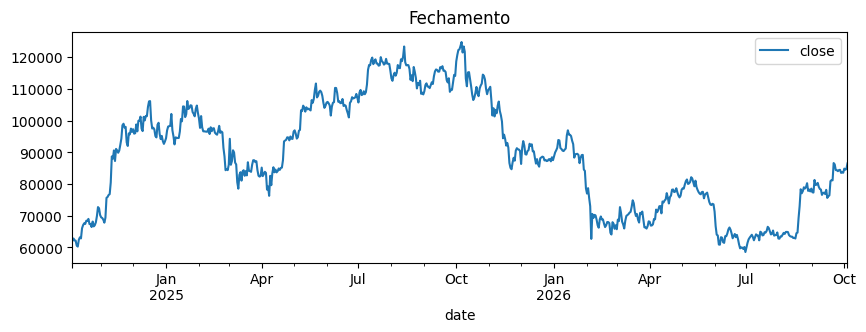

In [3]:
print(df.isna().sum())
print(df["date"].min(), "→", df["date"].max())
df.plot(x="date", y="close", figsize=(10, 3), title="Fechamento")
plt.show()

## 2. Features e alvo
`X[i]` = fechamentos de 7 dias; `y[i]` = fechamento do dia seguinte.

In [4]:
close = df["close"].to_numpy(dtype=float)
X = np.stack([close[i:i + N_LAGS] for i in range(len(close) - N_LAGS)])
y = close[N_LAGS:]
X.shape, y.shape

((723, 7), (723,))

## 3. Divisão cronológica
Série temporal: o passado treina, o futuro testa. **Sem embaralhar.**

In [5]:
cut = int(len(X) * 0.8)
X_tr, X_te, y_tr, y_te = X[:cut], X[cut:], y[:cut], y[cut:]
len(X_tr), len(X_te)

(578, 145)

## 4. Treino e métricas

In [6]:
candidates = {
    "linear": LinearRegression(),
    "random_forest": RandomForestRegressor(n_estimators=100, random_state=42),
}
results = {}
for name, model in candidates.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    results[name] = (model, pred, mean_absolute_error(y_te, pred), mean_squared_error(y_te, pred) ** 0.5)
    print(f"{name}: MAE={results[name][2]:.2f}  RMSE={results[name][3]:.2f}")

best = min(results, key=lambda k: results[k][2])
print("Melhor (menor MAE):", best)

linear: MAE=1035.79  RMSE=1481.98
random_forest: MAE=1955.52  RMSE=2450.33
Melhor (menor MAE): linear


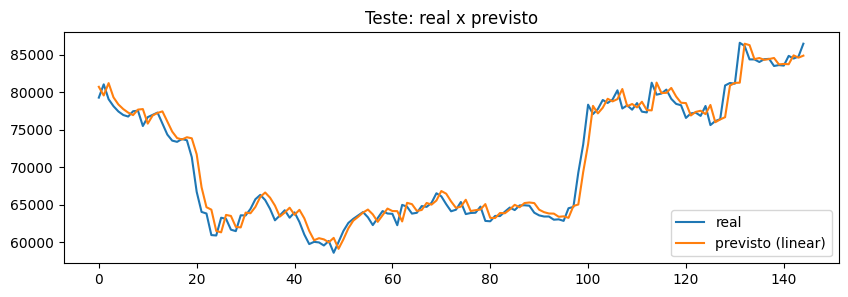

In [7]:
plt.figure(figsize=(10, 3))
plt.plot(y_te, label="real")
plt.plot(results[best][1], label=f"previsto ({best})")
plt.legend(); plt.title("Teste: real x previsto"); plt.show()

## 5. Exportar o artefato
O backend carrega este arquivo (via volume compartilhado `models/`).

In [8]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump({"model": results[best][0], "n_lags": N_LAGS, "name": best}, MODEL_PATH)
print("Salvo em", os.path.abspath(MODEL_PATH))

Salvo em /Users/enzopiolcerutti/Documents/Inteli/M07/atividade-mlu-docker/models/model.joblib


In [ ]:
print(close[-N_LAGS:].tolist())

[83502.609375, 83622.4296875, 83553.8515625, 84853.1015625, 84497.2109375, 84763.578125, 86480.3046875]
